## Part 4

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import ast

os.makedirs("assets", exist_ok=True)
print("Environment set up successfully.")

Environment set up successfully.


In [2]:
q_agent_logs_path = "../agent/q_learning_agent.jsonl"
random_agent_logs_path = "../agent/random_agent.jsonl"

In [3]:
def filter_completed_logs(filepath):
    """Reads a log file and returns a list of log entries where 'done' is true."""
    completed_logs = []
    
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found.")
        return completed_logs
    
    line_count = 0
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                line_count += 1
                entry = json.loads(line)
                # Filter where 'done' is explicitly true
                if entry.get("done") == True:
                    completed_logs.append(entry)
                    
    return completed_logs, line_count


def filter_successful_entries(logs):
    """Filters a list of log entries where the agent successfully placed the correct order."""
    successful_logs = []
    
    for entry in logs:
        info = entry.get("info")
        if isinstance(info, dict):
            reason = info.get("reason", "")
            if reason and "correct order placed" in reason:
                successful_logs.append(entry)
                
    return successful_logs

def calculate_error_rate_ci(failures, total_attempts, confidence=0.95):
    """Calculates the error rate percentage and its confidence interval."""
    if total_attempts == 0:
        return 0.0, 0.0, 0.0
    
    error_rate = failures / total_attempts
    
    # Wilson interval calculation for the error rate
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    denominator = 1 + z**2 / total_attempts
    center_adjusted = (error_rate + z**2 / (2 * total_attempts)) / denominator
    margin = z * np.sqrt((error_rate * (1 - error_rate) + z**2 / (4 * total_attempts)) / total_attempts) / denominator
    
    ci_low = max(0.0, center_adjusted - margin)
    ci_high = min(1.0, center_adjusted + margin)
    
    return error_rate * 100, ci_low * 100, ci_high * 100

In [4]:
random_agent_logs, total_random_agent_logs = filter_completed_logs(random_agent_logs_path)
q_agent_logs, total_q_agent_logs = filter_completed_logs(q_agent_logs_path)

random_success_agent_logs = filter_successful_entries(random_agent_logs)
q_success_agent_logs = filter_successful_entries(q_agent_logs)
len(random_agent_logs), len(q_agent_logs)

(216, 2520)

In [5]:
random_failures = len(random_agent_logs) - len(random_success_agent_logs)
q_failures = len(q_agent_logs) - len(q_success_agent_logs)
random_failures, q_failures

(214, 878)

In [6]:
random_ci = calculate_error_rate_ci(random_failures, len(random_agent_logs))
q_ci = calculate_error_rate_ci(q_failures, len(q_agent_logs))

In [28]:
df = pd.DataFrame(q_agent_logs)
seeds = [42, 101, 2024]

df = df[df["seed"].isin(seeds)].copy()

# Reset episode numbering within each training run
df["episode_in_run"] = df.groupby("seed").cumcount()

# 12 goals per epoch, 20 epochs per run
df["epoch"] = (df["episode_in_run"] // 12) + 1

df["episode_in_run"] = (df["episode"] - 1) % 240
df["epoch"] = (df["episode_in_run"] // 12) + 1
# ---------------------------------------------------------
# 2. Define what counts as a successful episode
# ---------------------------------------------------------

# Based on your log format, orderComplete=True means
# the shopping task was successfully completed.
df["success"] = df["observation"].apply(
    lambda obs: obs.get("orderComplete", False)
)


# ---------------------------------------------------------
# 3. Calculate success rate for every epoch/run
# ---------------------------------------------------------

epoch_results = (
    df.groupby(["seed", "epoch"])
      .agg(
          successes=("success", "sum"),
          episodes=("success", "count"),
      )
      .reset_index()
)

epoch_results["success_rate"] = (
    epoch_results["successes"] /
    epoch_results["episodes"] *
    100
)
# print(epoch_results)

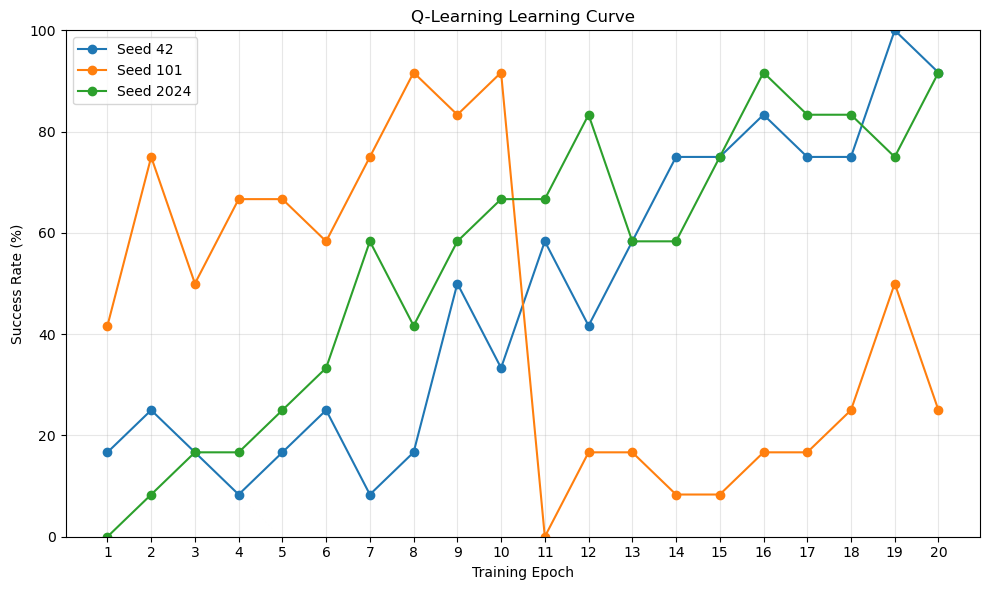

In [29]:
plt.figure(figsize=(10, 6))

for seed, group in epoch_results.groupby("seed"):
    plt.plot(
        group["epoch"],
        group["success_rate"],
        marker="o",
        label=f"Seed {seed}"
    )

plt.xlabel("Training Epoch")
plt.ylabel("Success Rate (%)")
plt.title("Q-Learning Learning Curve")
plt.xticks(range(1, 21))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
fail, succeed = df["success"].value_counts()
percent_success = succeed / (fail+succeed)*100.0
print(percent_success)

48.75


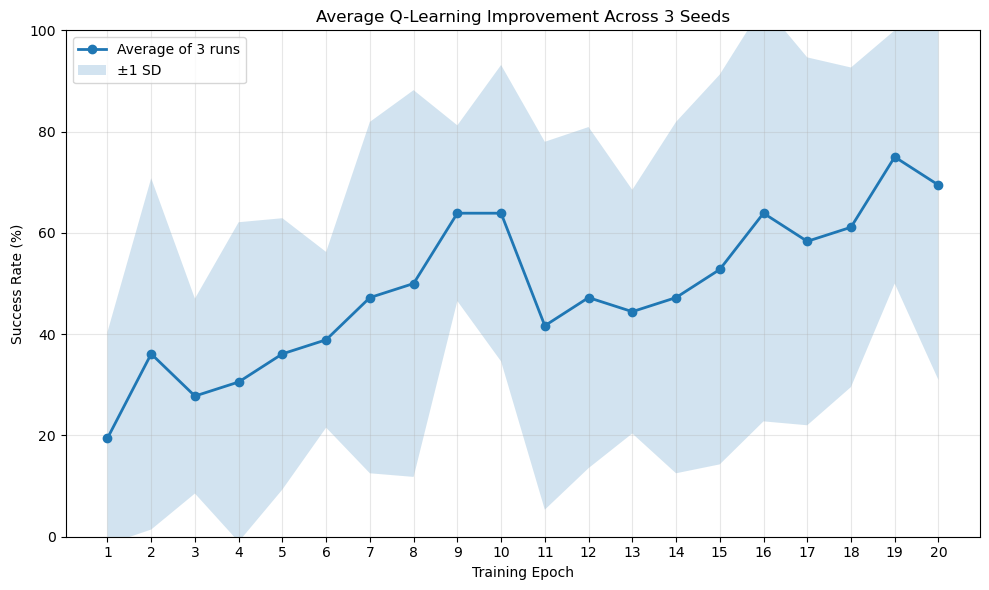

In [9]:
average = (
    epoch_results
    .groupby("epoch")["success_rate"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    average["epoch"],
    average["mean"],
    marker="o",
    linewidth=2,
    label="Average of 3 runs"
)

plt.fill_between(
    average["epoch"],
    average["mean"] - average["std"],
    average["mean"] + average["std"],
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Training Epoch")
plt.ylabel("Success Rate (%)")
plt.title("Average Q-Learning Improvement Across 3 Seeds")
plt.xticks(range(1, 21))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
df = pd.DataFrame(random_agent_logs)
seeds = [42, 101, 2024]

# df = df[df["seed"].isin(seeds)].copy()

# Reset episode numbering within each training run
df["episode_in_run"] = df.groupby("seed").cumcount()

# 12 goals per epoch, 20 epochs per run
df["epoch"] = (df["episode_in_run"] // 12) + 1

df["episode_in_run"] = (df["episode"] - 1) % 240
df["epoch"] = (df["episode_in_run"] // 12) + 1
# ---------------------------------------------------------
# 2. Define what counts as a successful episode
# ---------------------------------------------------------

# Based on your log format, orderComplete=True means
# the shopping task was successfully completed.
df["success"] = df["observation"].apply(
    lambda obs: obs.get("orderComplete", False)
)

# ---------------------------------------------------------
# 3. Calculate success rate for every epoch/run
# ---------------------------------------------------------

epoch_results = (
    df.groupby(["seed", "epoch"])
      .agg(
          successes=("success", "sum"),
          episodes=("success", "count"),
      )
      .reset_index()
)

epoch_results["success_rate"] = (
    epoch_results["successes"] /
    epoch_results["episodes"] *
    100
)
# print(epoch_results)

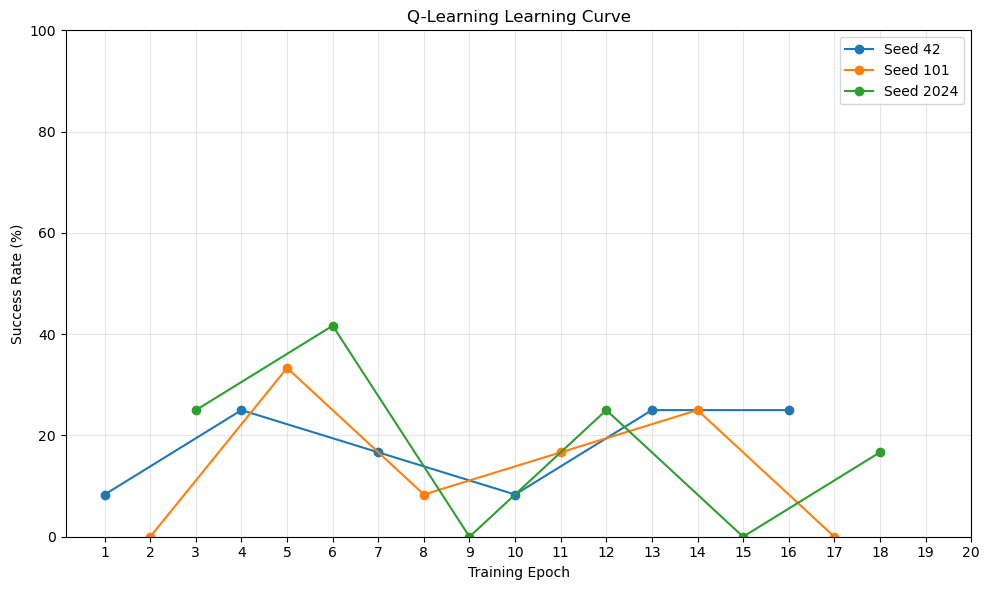

In [13]:
plt.figure(figsize=(10, 6))

for seed, group in epoch_results.groupby("seed"):
    plt.plot(
        group["epoch"],
        group["success_rate"],
        marker="o",
        label=f"Seed {seed}"
    )

plt.xlabel("Training Epoch")
plt.ylabel("Success Rate (%)")
plt.title("Q-Learning Learning Curve")
plt.xticks(range(1, 21))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

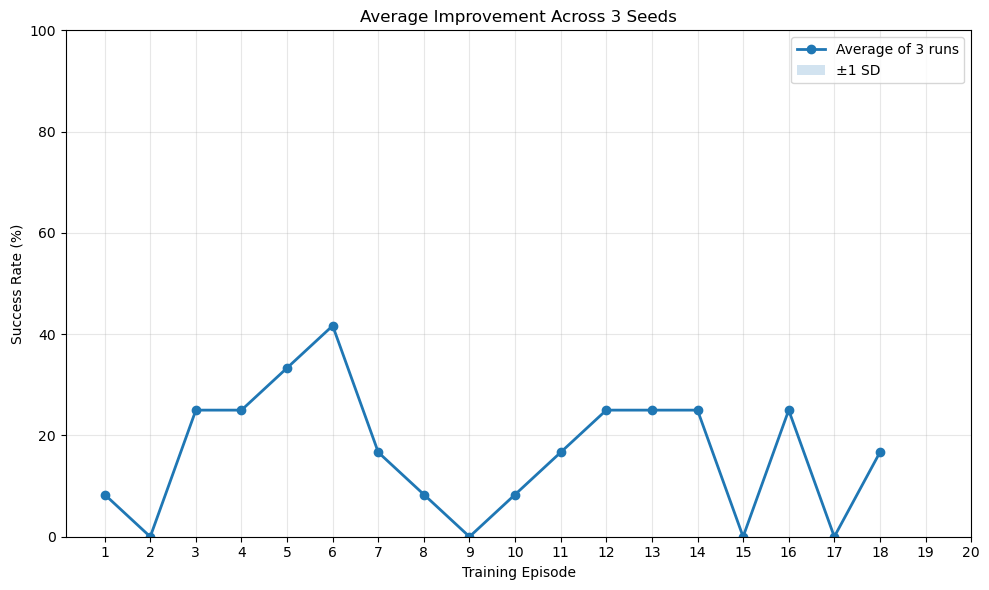

In [14]:
average = (
    epoch_results
    .groupby("epoch")["success_rate"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    average["epoch"],
    average["mean"],
    marker="o",
    linewidth=2,
    label="Average of 3 runs"
)

plt.fill_between(
    average["epoch"],
    average["mean"] - average["std"],
    average["mean"] + average["std"],
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Training Episode")
plt.ylabel("Success Rate (%)")
plt.title("Average Improvement Across 3 Seeds")
plt.xticks(range(1, 21))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# Random agent success rate:
fail, succeed = df["success"].value_counts()
percent_success = succeed / (fail+succeed)*100.0
print(percent_success)


16.666666666666664
